# Gaussian process flow modeling

Reconstruct a divergence-free 2D velocity field from sparse noisy samples with a Gaussian process, then advect particles through it. Fully offline and reproducible.

In [1]:
import numpy as np
from flowgp import (
    synthetic_flow_field, make_observations, train_test_split_points,
    GPFieldModel, advect_particles, divergence,
)

field = synthetic_flow_field(n=45, seed=0)
interior = divergence(field)[2:-2, 2:-2]
print('mean |divergence| interior:', float(np.abs(interior).mean()))

mean |divergence| interior: 0.014560447402704381


In [2]:
points, vel = make_observations(field, n_obs=200, noise=0.05, seed=0)
p_tr, v_tr, p_te, v_te = train_test_split_points(points, vel, seed=0)
gp = GPFieldModel(length_scale=1.0).fit(p_tr, v_tr)
print('held-out reconstruction RMSE:', round(gp.score_rmse(p_te, v_te), 4))

held-out reconstruction RMSE: 0.244


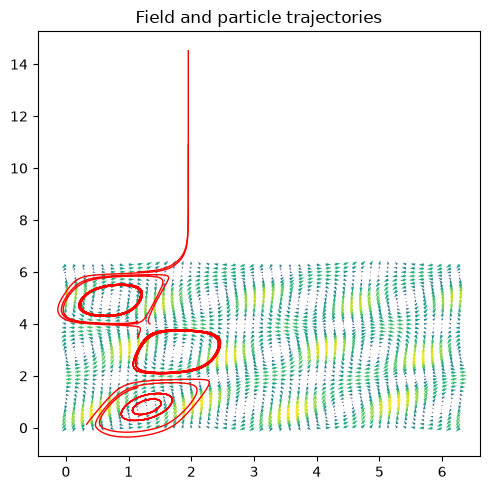

In [3]:
import matplotlib.pyplot as plt

starts = np.column_stack([np.full(10, field.xs[8]), np.linspace(field.ys[2], field.ys[-3], 10)])
traj = advect_particles(field, starts, n_steps=150, dt=0.03)
gx, gy = np.meshgrid(field.xs, field.ys)
plt.figure(figsize=(5, 5))
plt.quiver(gx, gy, field.u, field.v, np.hypot(field.u, field.v), cmap='viridis')
for p in range(traj.shape[1]):
    plt.plot(traj[:, p, 0], traj[:, p, 1], 'r', lw=1)
plt.title('Field and particle trajectories'); plt.tight_layout(); plt.show()